In [1]:
import scanpy as sc
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os

# Calculate traits and covs based on Matrix D1 and D1D2 proportions

Bican h5ad have been generated using `/home/gdallagl/myworkdir/XDP/script/multiple_samples_analysis/find_spatial_grad_gene_MSN_types.ipynb`

### Load adatas OBS

dont need entire adata

In [2]:
# just need m1 and d1d2 to calculate trait
msn_type_path_dict = {
    "eMSN_D1D2": {
        "path": "/home/gdallagl/myworkdir/XDP/data/BICAN/whole_BICAN_ezra/eMSN_D1D2/eMSN_D1D2.h5ad", 
        "zone_col": "zone_4", "donor_col": "donor_id", "ct_for_deg": "eMSN_D1D2"}, 
    # "Patch_D1": {"path": "/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/STR_D1_Patch_MSN.qs", "zone_col": "Final_Zone_Assignments_No_Smooth", "donor_col": "donor", "x": "x_um2", "y": "y_um2"}, # gs://macosko_data/akraft/Zonal_Objects/
    # "Patch_D2": {"path": "/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/STR_D2_Patch_MSN.qs", "zone_col": "Final_Zone_Assignments_No_Smooth", "donor_col": "donor", "x": "x_um2", "y": "y_um2"}, # gs://macosko_data/akraft/Zonal_Objects/
    "Matrix_D1": {
        "path": "/home/gdallagl/myworkdir/XDP/data/BICAN/whole_BICAN_ezra/Matrix_D1/Matrix_D1.h5ad", 
        "zone_col": "zone", "donor_col": "donor_id", "ct_for_deg": "Matrix_D1"},
    #"Matrix_D2": {"path": "/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/STR_D2_Matrix_MSN.qs", "zone_col": "D2_Matrix_Zone", "donor_col": "donor", "x": "x_position", "y": "y_position"}, #gs://macosko_data/akraft/Human_Striatum_Slide-tags/High_Quality_by_Celltype/
}

In [3]:
adata_d1d2 = sc.read_h5ad(msn_type_path_dict["eMSN_D1D2"]["path"])
adata_d1d2_obs = adata_d1d2.obs.copy()

In [4]:
# see wchich tissues there are
adata_d1d2_obs["brain_region_abbreviation"].unique()
adata_d1d2_obs["tissue"].unique()
adata_d1d2_obs["sample_outlier"].unique()

[NaN, 'conformity outlier', 'unexpected neurons', 'low nuclei count']
Categories (3, object): ['conformity outlier', 'low nuclei count', 'unexpected neurons']

In [5]:
tmp = adata_d1d2_obs[
    adata_d1d2_obs["tissue"].isin(["CaH", "Pu"]) &
    adata_d1d2_obs["sample_outlier"].isna() &
    adata_d1d2_obs["donor_outlier"].isna() &
    adata_d1d2_obs["gex_donor_outlier"].isna() &
    adata_d1d2_obs["gex_donor_celltype_outlier"].isna() 
    ]
tmp

display(tmp.groupby("donor_id")["tissue"].nunique())
display(tmp.groupby("donor_id")["village"].nunique())

# take only samples that: have 2 tissues and 2 villages
# take only samples that: have 2 tissues and 2 villages
tmp = tmp[
    (tmp.groupby("donor_id")["tissue"].transform('nunique') == 2) & 
    (tmp.groupby("donor_id")["village"].transform('nunique') == 2)
]
tmp["donor_id"].nunique()

/tmp/ipykernel_4414/256958231.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(tmp.groupby("donor_id")["tissue"].nunique())


donor_id
MD6366        2
MD6417        1
MD6424        2
MD6429        2
MD6431        1
             ..
UMBEB23076    1
UMBEB23083    0
UMBEB23100    0
UMBEB23127    2
UMBEB24009    2
Name: tissue, Length: 171, dtype: int64

/tmp/ipykernel_4414/256958231.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(tmp.groupby("donor_id")["village"].nunique())


donor_id
MD6366        2
MD6417        1
MD6424        2
MD6429        2
MD6431        1
             ..
UMBEB23076    1
UMBEB23083    0
UMBEB23100    0
UMBEB23127    2
UMBEB24009    2
Name: village, Length: 171, dtype: int64

/tmp/ipykernel_4414/256958231.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (tmp.groupby("donor_id")["tissue"].transform('nunique') == 2) &
/tmp/ipykernel_4414/256958231.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (tmp.groupby("donor_id")["village"].transform('nunique') == 2)


114

In [16]:
adata_d1d2 = sc.read_h5ad(msn_type_path_dict["eMSN_D1D2"]["path"])
adata_d1d2_obs = adata_d1d2.obs.copy()
d1d2_donors = set(adata_d1d2_obs[msn_type_path_dict["eMSN_D1D2"]["donor_col"]].values)

adata_m1 = sc.read_h5ad(msn_type_path_dict["Matrix_D1"]["path"])
adata_m1_obs = adata_m1.obs.copy()
m1_donors = set(adata_m1_obs[msn_type_path_dict["Matrix_D1"]["donor_col"]].values)

common_donors = d1d2_donors.intersection(m1_donors)

adata_d1d2 = adata_d1d2[adata_d1d2_obs[msn_type_path_dict["eMSN_D1D2"]["donor_col"]].isin(common_donors), :]
adata_m1 = adata_m1[adata_m1_obs[msn_type_path_dict["Matrix_D1"]["donor_col"]].isin(common_donors), :]


# concat
obs = pd.concat([adata_d1d2.obs, adata_m1.obs], axis=0)
obs["ct"] = obs["ct_for_deg"].map({
    "eMSN_D1D2": "eMSN_D1D2", 
    "Matrix_D1": "Matrix", "Matrix_D2": "Matrix",
    "Patch_D1": "Patch", "Patch_D2": "Patch"
})
obs["zone"] = obs["zone"].astype(str)


In [17]:
obs = obs[
    obs["tissue"].isin(["CaH", "Pu"]) &
    obs["sample_outlier"].isna() &
    obs["donor_outlier"].isna() &
    obs["gex_donor_outlier"].isna() &
    obs["gex_donor_celltype_outlier"].isna() 
    ]
obs

display(obs.groupby("donor_id")["tissue"].nunique())
display(obs.groupby("donor_id")["village"].nunique())

# take only samples that: have 2 tissues and 2 villages
# take only samples that: have 2 tissues and 2 villages
obs = obs[
    (obs.groupby("donor_id")["tissue"].transform('nunique') == 2) & 
    (obs.groupby("donor_id")["village"].transform('nunique') == 2)
]
obs["donor_id"].nunique()

/tmp/ipykernel_89897/4238291618.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(obs.groupby("donor_id")["tissue"].nunique())


donor_id
MD6366        2
MD6417        1
MD6424        2
MD6429        2
MD6431        1
             ..
UMBEB23076    1
UMBEB23083    0
UMBEB23100    1
UMBEB23127    2
UMBEB24009    2
Name: tissue, Length: 171, dtype: int64

/tmp/ipykernel_89897/4238291618.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(obs.groupby("donor_id")["village"].nunique())


donor_id
MD6366        2
MD6417        1
MD6424        2
MD6429        2
MD6431        1
             ..
UMBEB23076    1
UMBEB23083    0
UMBEB23100    1
UMBEB23127    2
UMBEB24009    2
Name: village, Length: 171, dtype: int64

/tmp/ipykernel_89897/4238291618.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (obs.groupby("donor_id")["tissue"].transform('nunique') == 2) &
/tmp/ipykernel_89897/4238291618.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (obs.groupby("donor_id")["village"].transform('nunique') == 2)


114

In [8]:

# d1d2 = sc.read_h5ad(msn_type_path_dict["eMSN_D1D2"]["path"], backed='r')
# d1d2_obs = d1d2.obs.copy()
# d1d2_obs["ct_for_deg"] = "eMSN_D1D2"
# d1d2_obs["zone"] = d1d2_obs["zone_4"].copy()

# d1d2_samples = d1d2_obs["donor_id"].unique().tolist()
# print(len(d1d2_samples), "unique donors in eMSN_D1D2")

# processed = []
# for cell_type, infos in list(msn_type_path_dict.items())[:]:

#     print(cell_type)

#     if cell_type == "eMSN_D1D2":
#         processed.append(d1d2_obs)
#     else:
#         adata = sc.read_h5ad(infos["path"], backed='r')
#         adata_obs = adata.obs.copy()
#         print(adata_obs["donor_id"].nunique(), "unique donors in", cell_type)
#         adata_obs = adata_obs[adata_obs["donor_id"].isin(d1d2_samples)].copy()  # keep only donors that are in eMSN_D1D2
#         adata_obs["ct_for_deg"] = infos["ct_for_deg"]
#         adata_obs["zone"] = adata_obs[infos["zone_col"]].copy()

#         processed.append(adata_obs)

# # concat
# obs = pd.concat(processed)
# obs["ct"] = obs["ct_for_deg"].map({
#     "eMSN_D1D2": "eMSN_D1D2", 
#     "Matrix_D1": "Matrix", "Matrix_D2": "Matrix",
#     "Patch_D1": "Patch", "Patch_D2": "Patch"
# })
# obs["zone"] = obs["zone"].astype(str)


In [18]:
# show donors with both cell types
donors_with_both_cell_types = obs.groupby(["donor_id", "ct_for_deg"]).size().unstack(fill_value=0).query("eMSN_D1D2 > 0 and Matrix_D1 > 0")
display(donors_with_both_cell_types)
donors_with_both_cell_types = donors_with_both_cell_types.index.tolist() 
donors_with_both_cell_types

# filter 
obs = obs[obs["donor_id"].isin(donors_with_both_cell_types)].copy()

/tmp/ipykernel_89897/1677903209.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donors_with_both_cell_types = obs.groupby(["donor_id", "ct_for_deg"]).size().unstack(fill_value=0).query("eMSN_D1D2 > 0 and Matrix_D1 > 0")


ct_for_deg,Matrix_D1,eMSN_D1D2
donor_id,,
MD6366,2418,357
MD6424,1837,327
MD6429,976,207
MD6433,1050,114
MD6434,943,110
...,...,...
UMBEB23048,958,71
UMBEB23060,1459,36
UMBEB23073,1936,123


In [10]:
# # Need to add ids

# # # mapping between donors ids versiosn
# # a = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/BICAN/D1_matrix_6_clusters_no56.h5ad", backed="r")
# # obs = a.obs[["donor", "donor_id"]].dropna().drop_duplicates().set_index("donor_id").copy()
# # obs = obs[obs.index != "nan"]
# # obs.to_csv("/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/spatial_bican_ids_conversion.csv")

# ids_df = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/spatial_bican_ids_conversion.csv")
# ids_df

# adata.obs.drop(columns=["donor_id"], inplace=True)
# adata.obs = adata.obs.merge(ids_df, left_on="donor", right_on="donor", how="left")

# adata = adata[~adata.obs["donor_id"].isna(), :].copy()  # remove cells with no donor_id

# adata.obs[["donor_id", "donor"]].drop_duplicates().sort_values("donor_id")

In [11]:
# for s in adata.obs["donor_id"].unique()[:2]:
#     sc.pl.embedding(adata[adata.obs["donor_id"] == s], basis="spatial", color=["ct_for_deg"], title=f"{s} - {adata[adata.obs['donor_id'] == s].shape[0]} cells")
#     #break

### Calcutle trait

In [19]:
df_meta = obs.drop_duplicates("donor_id").set_index("donor_id")[["age"]]
df_meta["donor_id"] = df_meta.index.copy()
df_meta["m1_z1_raw_trait"] = np.nan
df_meta["m1_z1_trait"] = np.nan
df_meta["d1d1_z2_cov"] = np.nan

df_meta

,age,donor_id,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov
donor_id,,,,,
MS323252,90,MS323252,NaN,NaN,NaN
MD6574,46,MD6574,NaN,NaN,NaN
MS68083,90,MS68083,NaN,NaN,NaN
MS728919,56,MS728919,NaN,NaN,NaN
MS107236,58,MS107236,NaN,NaN,NaN
...,...,...,...,...,...
PT13717,44,PT13717,NaN,NaN,NaN
PT13641,42,PT13641,NaN,NaN,NaN
PT13702,41,PT13702,NaN,NaN,NaN


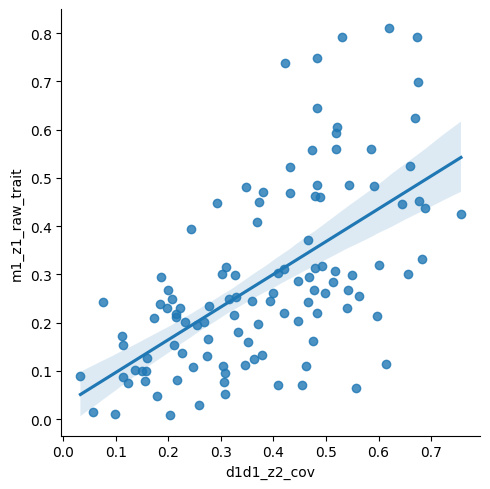

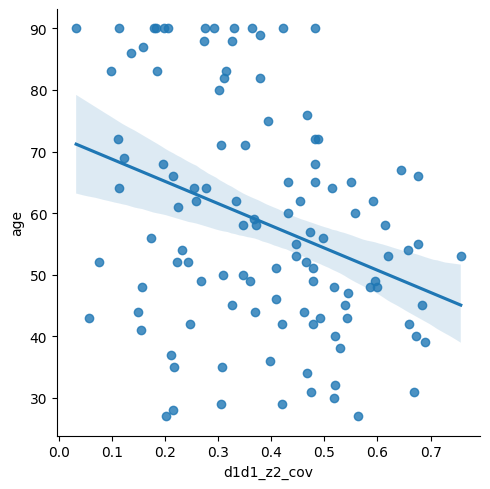

,age,donor_id,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total
donor_id,,,,,,
MS323252,90,MS323252,0.738263,1.745127,0.421875,3408.0
MD6574,46,MD6574,0.302505,0.393901,0.408360,2076.0
MS68083,90,MS68083,0.089646,-1.135854,0.032885,6336.0
MS728919,56,MS728919,0.261253,0.120964,0.497797,2155.0
MS107236,58,MS107236,0.450442,0.787358,0.372093,3057.0
...,...,...,...,...,...,...
PT13717,44,PT13717,0.100512,-1.018303,0.149733,1562.0
PT13641,42,PT13641,0.524493,1.178714,0.658960,1184.0
PT13702,41,PT13702,0.078912,-1.271640,0.155405,2205.0


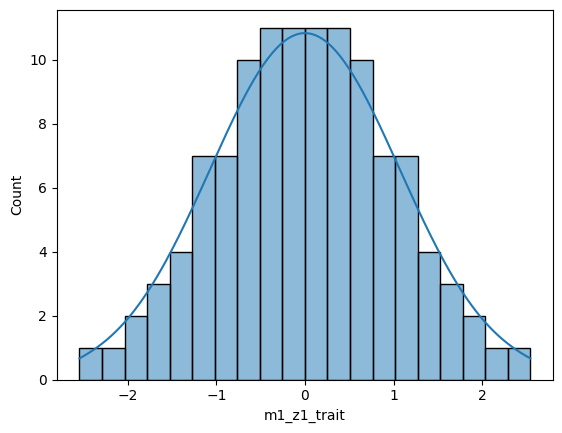

: 

In [ ]:
import numpy as np
from scipy.stats import norm

def rint(series):
    """Rank-based inverse-normal transform (Blom), NaN-safe."""
    x = series.copy()
    mask = x.notna()                      # ignore donors with no value
    ranks = x[mask].rank(method="average")
    n = mask.sum()
    # Blom offset c = 3/8 is the standard choice
    x[mask] = norm.ppf((ranks - 3/8) / (n - 2*3/8 + 1))
    return x

for donor in df_meta.index:

    obs_donor = obs[obs["donor_id"] == donor].copy()

    n_m1_total = len(obs_donor[obs_donor["ct_for_deg"] == "Matrix_D1"])
    n_m1_z1    = len(obs_donor[(obs_donor["ct_for_deg"] == "Matrix_D1") & (obs_donor["zone"] == "1")])

    n_espn_total = len(obs_donor[obs_donor["ct_for_deg"] == "eMSN_D1D2"])
    n_espn_z2    = len(obs_donor[(obs_donor["ct_for_deg"] == "eMSN_D1D2") & (obs_donor["zone"] == "2")])

    # guard against donors with zero matrix-D1 cells -> NaN instead of crash
    df_meta.loc[donor, "n_m1_total"]        = n_m1_total
    df_meta.loc[donor, "m1_z1_raw_trait"]   = n_m1_z1 / n_m1_total if n_m1_total > 0 else np.nan
    df_meta.loc[donor, "d1d1_z2_cov"]       = n_espn_z2 / n_espn_total if n_espn_total > 0 else np.nan

# AFTER the loop: transform the whole column at once
df_meta["m1_z1_trait"] = rint(df_meta["m1_z1_raw_trait"])

# add to adata.obs
#adata.obs = adata.obs.merge(df_meta[["m1_z1_trait", "m1_z1_raw_trait", "d1d1_z2_cov"]], left_on="donor_id", right_index=True, how="left")   

sns.lmplot(data=df_meta, x="d1d1_z2_cov", y="m1_z1_raw_trait"); plt.show()
sns.lmplot(data=df_meta, x="d1d1_z2_cov", y="age"); plt.show()

sns.histplot(data=df_meta, x="m1_z1_trait", bins=20, kde=True)
df_meta

In [14]:
# # plot donrowith min raw trait
# sc.pl.embedding(adata[adata.obs["m1_z1_raw_trait"] == df_meta["m1_z1_raw_trait"].min()], basis="spatial", color=["ct_for_deg"], title=f"All donors - {adata.shape[0]} cells")
# sc.pl.embedding(adata[adata.obs["m1_z1_raw_trait"] == df_meta["m1_z1_raw_trait"].min()], basis="spatial", color=["zone"], title=f"All donors - {adata.shape[0]} cells")

# Download from bucket vcf (already normalised in this case)

```bash
gsutil -m cp 
gs://macosko_data/leematth/sharing/Striatum_Zones_Paper/Updated_Objects/vcfs/gvs_concat_outputs_2026-04-24.donors_renamed_filtered_norm.vcf.gz 
gs://macosko_data/leematth/sharing/Striatum_Zones_Paper/Updated_Objects/vcfs/gvs_concat_outputs_2026-04-24.donors_renamed_filtered_norm.vcf.gz.tbi 
.
```

# Install bcftools podman 

To call container one command at a time
```bash
podman run \
    --rm \
    -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data \
    quay.io/biocontainers/bcftools:1.21--h8b25389_0 \
    ... command ...
```

```bash
# lisg header of vs f
    bcftools view -h /data/gvs_concat_outputs_2026-04-24.donors_renamed_filtered_norm.vcf.gz
# list donros
    bcftools query -l /data/gvs_concat_outputs_2026-04-24.donors_renamed_filtered_norm.vcf.gz
```

# Prepare VCF files

In [4]:
VCF_FOLDER = "/home/gdallagl/myworkdir/XDP/data/BICAN/vcf"

RAW_VCF  = "whole_bican_raw/raw.vcf.gz"   
RAW_TBI  = "whole_bican_raw/raw.vcf.gz.tbi"

NORM_VCF = "whole_bican_norm/norm.vcf.gz"
NORM_TBI = "whole_bican_norm/norm.vcf.gz.tbi"

GENES_BED = ["MSH3", "PMS2"]
BED = "subset/genes.bed"
GENOME = "GRCh38"
FLANK = 20000 # ±20 kb around each gene (regulatory + nearby modifier variants)

# bith by gene and samples
TYPE = "bcf"  # or "bcf"
EXT = {"vcf": "vcf.gz", "bcf": "bcf"}[TYPE]
OFLAG = "-Ob" if TYPE == "bcf" else "-Oz"
PLINK_INFLAG = "--bcf" if TYPE == "bcf" else "--vcf"

SUBSET_VCF        = f"subset/candidate.{EXT}"
SUBSET_NORM_VCF   = f"subset/candidate.norm.{EXT}"

SUBSET_PGEN = "subset/plink/candidate"
SUBSET_PGEN_NORM = "subset/plink/candidate_norm"

MOUNT = VCF_FOLDER
IMAGE_BCFTOOLS = "quay.io/biocontainers/bcftools:1.21--h8b25389_0"
IMAGE_PLINK = "quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0"

### *) Build the .bed file --> ONLY if want to run analysis for subset of genome

file contianing the coodirnted of the 2 genes ( + 20Kb pairs flanks) inside which we want to study the SNPs

In [16]:
# Chekc how the chr stirng are formatted --< same must be in .bed file
cmd = f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} bcftools view -h {NORM_VCF}'
print(cmd)
!{cmd} | grep "^##contig" | head

# ATTENTION:  GRCh38  == assembly=38

podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data quay.io/biocontainers/bcftools:1.21--h8b25389_0 bcftools view -h whole_bican_norm/norm.vcf.gz
##contig=<ID=chr1,length=248956422,assembly=38>
##contig=<ID=chr2,length=242193529,assembly=38>
##contig=<ID=chr3,length=198295559,assembly=38>
##contig=<ID=chr4,length=190214555,assembly=38>
##contig=<ID=chr5,length=181538259,assembly=38>
##contig=<ID=chr6,length=170805979,assembly=38>
##contig=<ID=chr7,length=159345973,assembly=38>
##contig=<ID=chr8,length=145138636,assembly=38>
##contig=<ID=chr9,length=138394717,assembly=38>
##contig=<ID=chr10,length=133797422,assembly=38>
grep: write error: Broken pipe
Error: attaching to container 3b3f21db3371a327a281c7d43f2254ac890ba1bfdbff2b233618252d88f05426: write /dev/stdout: broken pipe


In [17]:
# very where the 2 genes are in the geinome
# ATTENTION the genome msut be the same used for normalisation

# Ensembl REST API (GRCh38) — gives exact gene coordinates
import requests

def gene_coords(symbol, build):
    server = "https://rest.ensembl.org" if build == "GRCh38" else "https://grch37.rest.ensembl.org"
    r = requests.get(f"{server}/lookup/symbol/homo_sapiens/{symbol}",
                     headers={"Content-Type": "application/json"})
    r.raise_for_status()
    d = r.json()
    return d["seq_region_name"], d["start"], d["end"], d["assembly_name"]

df_bed = pd.DataFrame(columns=["gene", "chrom", "start", "end", "assembly"])
for g in GENES_BED:
    chrom, start, end, asm = gene_coords(g, GENOME)
    assert asm.startswith(GENOME), f"{g} returned {asm}, not {GENOME}!"
    start = max(0, start - 1 - FLANK) #add flanks; BED start is 0-based, Ensembl start is 1-based -> subtract 1
    end = end + FLANK
    name_chr = "chr" + chrom
    df_bed = pd.concat([df_bed, pd.DataFrame([{"gene": g, "chrom": name_chr, "start": start, "end": end, "assembly": asm}])], ignore_index=True)

df_bed = df_bed.sort_values(["chrom", "start"]).reset_index(drop=True)
df_bed[["chrom", "start", "end", "gene"]].to_csv(
    f"{VCF_FOLDER}/{BED}", sep="\t", header=False, index=False
)

df_bed

,gene,chrom,start,end,assembly
0,MSH3,chr5,80634612,80900295,GRCh38
1,PMS2,chr7,5950924,6029130,GRCh38


### *) Find intersetions Samples: vcf and adata

In [18]:
# donro in vcf
samples_in_vcf = !podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} bcftools query -l {NORM_VCF}   

# Donors from the XDP snRNA-seq dataset (XDP-diseased only, with computed trait)
# ATTENTION: use orignal donorID
samples_in_adata = df_meta["donor_id"].dropna().tolist()

# Exact-match intersection: only donors whose IDs are identical in both files
print(f"Samples in adata:       {sorted(samples_in_adata)}")
print(f"Donors in VCF:          {sorted(samples_in_vcf)}")
samples_intersection = sorted(set(samples_in_adata) & set(samples_in_vcf))

print(f"Samples in adata:       {len(samples_in_adata)}")
print(f"Donors in VCF:                      {len(samples_in_vcf)}")
print(f"Exact-match intersection:           {len(samples_intersection)}")
print("\nMatched donors:"); print(samples_intersection)

# Check for donors in adata but NOT in VCF (possible ID format issue)
missing_from_vcf = set(samples_in_adata) - set(samples_in_vcf)
if missing_from_vcf:
    print(f"\nDonors in adata but NOT in VCF ({len(missing_from_vcf)}): {sorted(missing_from_vcf)}")
    print("→ Check for suffix/underscore differences in VCF sample names above")

Samples in adata:       ['MD6366', 'MD6424', 'MD6429', 'MD6433', 'MD6434', 'MD6471', 'MD6570', 'MD6574', 'MD6592', 'MD6596', 'MD6666', 'MD6670', 'MD6673', 'MD6676', 'MD6872', 'MD6927', 'MD6996', 'MD6998', 'MD9043', 'MD9047', 'MD9081', 'MD9085', 'MD9086', 'MD9129', 'MD9162', 'MD9168', 'MD9237', 'MD9244', 'MD9261', 'MLS02599', 'MLS02966', 'MLS04249', 'MLS05283', 'MLS14380', 'MS107236', 'MS114000', 'MS166169', 'MS169509', 'MS173213', 'MS176369', 'MS192778', 'MS203133', 'MS238999', 'MS30499', 'MS323252', 'MS351250', 'MS367449', 'MS40593', 'MS414785', 'MS437537', 'MS450300', 'MS458379', 'MS475110', 'MS495045', 'MS50719', 'MS524265', 'MS53636', 'MS544811', 'MS55134', 'MS554485', 'MS570561', 'MS581663', 'MS637967', 'MS6570', 'MS663744', 'MS68083', 'MS722238', 'MS728919', 'MS77500', 'MS841919', 'MS876075', 'MS878151', 'MS913848', 'MS914387', 'MS934006', 'MS935986', 'MS966845', 'MS986638', 'PT13641', 'PT13645', 'PT13661', 'PT13702', 'PT13706', 'PT13717', 'PT13818', 'PT13825', 'PT13889', 'PT1390

### Create subsetted vcf based on 1)interestign genes 2) samples

In [19]:
# Extract only the genomic windows defined in the BED file and only the donors present in the intersection.
cmd_sub = (
    f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} '
    f'bcftools view '
    #f'-R {BED} '                             # restrict to gene windows ATTENTION: FILTR ONLY IF NECESSARY!!!
    f'-s {",".join(samples_intersection)} '  # restrict to our donors
    f'{NORM_VCF} '                           # input (normalized whole-cohort VCF)
    f'--threads 40 '                           # use
    f'{OFLAG} -o {SUBSET_VCF}'
)
print("3a. Subsetting VCF:"); print(cmd_sub)
!{cmd_sub}

3a. Subsetting VCF:
podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data quay.io/biocontainers/bcftools:1.21--h8b25389_0 bcftools view -s MD6366,MD6424,MD6429,MD6433,MD6434,MD6471,MD6570,MD6574,MD6592,MD6596,MD6666,MD6670,MD6673,MD6676,MD6872,MD6927,MD6996,MD6998,MD9043,MD9047,MD9081,MD9085,MD9086,MD9129,MD9162,MD9168,MD9237,MD9244,MD9261,MLS02599,MLS02966,MLS04249,MLS05283,MLS14380,MS107236,MS114000,MS166169,MS169509,MS173213,MS176369,MS192778,MS203133,MS238999,MS30499,MS323252,MS351250,MS367449,MS40593,MS414785,MS437537,MS450300,MS458379,MS475110,MS495045,MS50719,MS524265,MS53636,MS544811,MS55134,MS554485,MS570561,MS581663,MS637967,MS6570,MS663744,MS68083,MS722238,MS728919,MS77500,MS841919,MS876075,MS878151,MS913848,MS914387,MS934006,MS935986,MS966845,MS986638,PT13641,PT13645,PT13661,PT13702,PT13706,PT13717,PT13818,PT13825,PT13889,PT13904,PT13921,PT13922,PT13932,PT13935,PT13965,PT13967,PT13983,PT13987,PT13990,PT13994,PT13998,PT14003,PT14012,PT14022,PT14023,PT

### Normalise subsetted version

Attention: need to have genome fasta 
```bash
gsutil cp gs://gcp-public-data--broad-references/hg38/v0/Homo_sapiens_assembly38.fasta .
mv Homo_sapiens_assembly38.fasta GRCh38.fasta
```

In [20]:
# Re-normalise the subsetted VCF
FASTA = "fasta_genome/GRCh38.fasta"
cmd_norm = (
    f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} '
    f'bcftools norm '
    f'-f {FASTA} '       # left-align + use reference for complex indels
    f'-m -any '          # split multi-allelic records
    f'{SUBSET_VCF} {OFLAG} -o {SUBSET_NORM_VCF}'
)
print("\nNormalising:"); print(cmd_norm)
!{cmd_norm}

# 3c. Index the normalised subset
IDX_FLAG = "-c" if TYPE == "bcf" else "-t"
cmd_idx = (
    f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} '
    f'bcftools index {IDX_FLAG} -f {SUBSET_NORM_VCF}'
)
print("\nIndexing:"); print(cmd_idx)
!{cmd_idx}


Normalising:
podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data quay.io/biocontainers/bcftools:1.21--h8b25389_0 bcftools norm -f fasta_genome/GRCh38.fasta -m -any subset/candidate.bcf -Ob -o subset/candidate.norm.bcf
Lines   total/split/joined/realigned/removed/skipped:	43726751/0/0/0/0/0

Indexing:
podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data quay.io/biocontainers/bcftools:1.21--h8b25389_0 bcftools index -c -f subset/candidate.norm.bcf


### Convert to plink file format + QC

In [21]:
# Convert VCF/BCF to plink2 binary (.pgen / .pvar / .psam)

os.makedirs(f"{VCF_FOLDER}/{SUBSET_PGEN.rsplit('/', 1)[0]}", exist_ok=True)

# plink2 needs sex known *at import time* to resolve chrX/chrY ploidy — it refuses to import
# otherwise ("chrX is present ... no sex information was provided"). We want to KEEP chrX
# (TAF1, the XDP disease gene, sits on chrX) rather than drop it with --autosome, so supply
# sex via --update-sex instead. Source: whole-cohort metadata (same file used later for the
# GWAS covariate, loaded here directly since this cell runs before that one).
sex_meta = pd.read_csv(
    "/home/gdallagl/myworkdir/XDP/data/BICAN/bican_metadata.csv", index_col=0
).drop_duplicates("donor_id").set_index("donor_id")[["imputed_sex"]]
sex_map = {"M": 1, "male": 1, "F": 2, "female": 2}
if sex_meta["imputed_sex"].dtype == object:
    sex_meta["imputed_sex"] = sex_meta["imputed_sex"].map(sex_map)
sex_meta["imputed_sex"] = sex_meta["imputed_sex"].fillna(0).astype(int)  # plink2 code: 0 = unknown

SEX_UPDATE_FILE = "subset/sex_update.txt"
sex_out = sex_meta.reset_index().rename(columns={"donor_id": "IID", "imputed_sex": "SEX"})
# psam is single-ID (#IID only, no FID) -- update-sex file must match that same ID system,
# a dual-ID (FID+IID) file fails to match even when the ID strings themselves are identical
sex_out[["IID", "SEX"]].to_csv(
    f"{VCF_FOLDER}/{SEX_UPDATE_FILE}", sep="\t", index=False, header=["#IID", "SEX"]
)
print(f"Sex-update file written -> {SEX_UPDATE_FILE}  "
      f"({len(sex_out)} donors, {(sex_out['SEX'] == 0).sum()} unknown)")

cmd = (f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} "
  f"plink2 {PLINK_INFLAG} {SUBSET_NORM_VCF} "
  f"--update-sex {SEX_UPDATE_FILE} "  # ATTENTION: resolve chrX/chrY ploidy instead of erroring out
  f"--split-par hg38 "                 # correctly separate PAR1/PAR2 from true chrX/chrY on GRCh38
  f"--set-all-var-ids '@:#:$r:$a' "
  f"--new-id-max-allele-len 100 missing "
  f"--make-pgen "
  f"--out {SUBSET_PGEN} --threads 4"
)
print("Converting to plink:", cmd)
!{cmd}

#  Quality-control the plink file
cmd_qc = (f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} "
  f"  plink2 --pfile {SUBSET_PGEN} "
  f"  --geno 0.05 "
  f"  --mind 0.1 "
  f"  --maf 0.05 "
  f"  --make-pgen --out {SUBSET_PGEN_NORM}")
print("\nQC:", cmd_qc)
!{cmd_qc}


Sex-update file written -> subset/sex_update.txt  (190 donors, 0 unknown)
Converting to plink: podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0 plink2 --bcf subset/candidate.norm.bcf --update-sex subset/sex_update.txt --split-par hg38 --set-all-var-ids '@:#:$r:$a' --new-id-max-allele-len 100 missing --make-pgen --out subset/plink/candidate --threads 4
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to subset/plink/candidate.log.
Options in effect:
  --bcf subset/candidate.norm.bcf
  --make-pgen
  --new-id-max-allele-len 100 missing
  --out subset/plink/candidate
  --set-all-var-ids @:#:$r:$a
  --split-par hg38
  --threads 4
  --update-sex subset/sex_update.txt

Start time: Sun Aug  9 17:17:07 2026
314189 MiB RAM detected, ~189215 available; reserving 157094 MiB for main
workspace.
Using up 

--bcf: subset/plink/candidate-temporary.pgen +
subset/plink/candidate-temporary.pvar.zst +
subset/plink/candidate-temporary.psam written.
114 samples (0 females, 0 males, 114 ambiguous; 114 founders) loaded from
subset/plink/candidate-temporary.psam.
length.
--split-par: 95557 chromosome codes changed.
43726751 variants loaded from subset/plink/candidate-temporary.pvar.zst.
Note: No phenotype data present.
--update-sex: 99 samples updated, 91 IDs not present.
Writing subset/plink/candidate.psam ... done.
Writing subset/plink/candidate.pvar ... 1010111112121313141415151616171718181919202021212222232324242525262627272828292930303131323233333434353536363737383839394040414142424343444445454646474748484949505051515252535354545555565657575858595960606161626263636464656566666767686869697070717172727373747475757676777778787979808081818282838384848585868687878888898990909191929293939494959596969797989899done.
Writing subset/plink/candidate.pgen ... 1011121314151617181920212223242526272829303132

### *) Calcualte PCs (on ALL snps and ALL samples)

dont use XY chr


In [22]:
# From: https://raw.githubusercontent.com/meyer-lab-cshl/plinkQC/master/inst/extdata/high-LD-regions-hg38-GRCh38.txt
long_range_ld = """chr1 47761740 51761740 LRLD1
chr1 47761740 51761740 1
chr2 85919365 100517106 2
chr2 89917298 89917322 3
chr2 87416141 87416186 4
chr2 87417804 87417863 5
chr2 87418924 87418981 6
chr1 144106678 144106709 7
chr14 87391719 87391996 8
chr9 40365644 40365693 9
chr2 182427027 189427029 10
chr3 47483505 49987563 11
chr3 83368158 86868160 12
chr5 44464140 51168409 13
chr5 129636407 132636409 14
chr6 25391792 33424245 15
chr6 26726947 26726981 16
chr6 57788603 58453888 17
chr6 61109122 61357029 18
chr6 61424410 61424451 19
chr9 64198500 64200392 20
chr6 139637169 142137170 21
chr7 54964812 66897578 22
chr7 62182500 62277073 23
chr12 34639034 34639084 24
chr14 94658026 94658080 25
chr17 43159541 43159574 26
chr2 135275091 135275210 27
chr1 181955019 181955047 28
chr22 30060084 30060162 29
chr9 88958735 88959017 30
chr2 207609786 207609808 31
chr22 42980497 42980522 32
chr20 4031884 4032441 33
chr8 8105067 12105082 34
chr8 43025699 48924888 35
chr8 47303500 47317337 36
chr8 110918594 113918595 37
chr10 36671065 43184546 38
chr10 41693521 41885273 39
chr1 125169943 125170022 40
chr11 88127183 91127184 41
chr12 32955798 41319931 42
chr20 33948532 36438183 43
"""
LRLD_FILE = "fasta_genome/long_range_ld_GRCh38.txt"  # relative to VCF_FOLDER/MOUNT — must resolve inside the podman container
with open(f"{VCF_FOLDER}/{LRLD_FILE}", "w") as f:
    f.write(long_range_ld)


In [23]:
# ── Step 5a–b: Define PCA paths; convert full XDP VCF to plink; QC ───────────
# PCA is computed on the FULL XDP WGS cohort (all donors in the VCF),
# not just those with phenotype data. This gives more stable PC estimates.

PCA_FOLDER      = "whole_bican_PCA"             # all PCA output goes here
PCA_PGEN        = f"{PCA_FOLDER}/vcf_pca"          # pgen from all autosome variants
PCA_PGEN_QC     = f"{PCA_FOLDER}/vcf_pca_qc"      # pgen after MAF + geno filters
PCA_PGEN_PRUNED = f"{PCA_FOLDER}/vcf_pca_pruned"  # prefix for prune.in / prune.out
PCA_OUT         = f"{PCA_FOLDER}/PCA"              # final PCA output prefix
N_PCs           = 10                                # number of PCs to compute

os.makedirs(f"{VCF_FOLDER}/{PCA_FOLDER}", exist_ok=True)

# 5a. Convert full normalized XDP VCF → plink2 binary format (all donors)
print("Step 5a: Converting full VCF to plink...")
cmd = (f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} "
    f"plink2 --vcf {NORM_VCF} "
    f"--autosome " #exclude chrX, chrY, chrM; sex/MT chromosomes distort PCA
    f"--set-all-var-ids '@:#:$r:$a' " # chr:pos:ref:alt as variant ID
    f"--new-id-max-allele-len 100 missing " # very long alleles get ID "missing"
    f"--make-pgen --out {PCA_PGEN} --threads 4")
print(cmd); 
!{cmd}

# 5b. QC: remove low-frequency variants and high-missingness variants
print("\nStep 5b: QC for PCA...")
cmd_qc = (f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} "
    f"plink2 --pfile {PCA_PGEN} "
    f"--geno 0.05 " #drop variants missing in >5% of samples
    f"--maf 0.05 " #drop variants with minor allele frequency < 5%
    f"--make-pgen --out {PCA_PGEN_QC}")
print(cmd_qc); 
!{cmd_qc}



Step 5a: Converting full VCF to plink...
podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0 plink2 --vcf whole_bican_norm/norm.vcf.gz --autosome --set-all-var-ids '@:#:$r:$a' --new-id-max-allele-len 100 missing --make-pgen --out whole_bican_PCA/vcf_pca --threads 4
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to whole_bican_PCA/vcf_pca.log.
Options in effect:
  --autosome
  --make-pgen
  --new-id-max-allele-len 100 missing
  --out whole_bican_PCA/vcf_pca
  --set-all-var-ids @:#:$r:$a
  --threads 4
  --vcf whole_bican_norm/norm.vcf.gz

Start time: Sun Aug  9 17:19:25 2026
314189 MiB RAM detected, ~189102 available; reserving 157094 MiB for main
workspace.
Using up to 4 compute threads.
--vcf: 19417k variants scanned.

--vcf: 42107675 variants scanned (1619076 skipped).
--vcf: whole_bican_PCA/vcf_pca-temporary.pgen +
whole_bican_PCA/vcf_pca-temporary.pvar.zst +
whole_bican_PCA/vcf_pca-temporary.psam written.
289 samples (0 females, 0 males, 289 ambiguous; 289 founders) loaded from
whole_bican_PCA/vcf_pca-temporary.psam.
length.
42107675 variants loaded from whole_bican_PCA/vcf_pca-temporary.pvar.zst.
Note: No phenotype data present.
Writing whole_bican_PCA/vcf_pca.psam ... done.
Writing whole_bican_PCA/vcf_pca.pvar ... 10101112121313141415161617171818192020212122222324242525262627282829293030313232333334343536363737383839404041414242434444454546464748484949505051525253535454555656575758585960606161626263646465656666676868696970707172727373747475767677777878798080818182828384848585868687888889899090919292939394949596969797989899done.
Writing whole_bican_PCA/vcf_pca.pgen ... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737

In [24]:
# ── Step 5c–d: LD-prune variants, then compute ancestry PCA ──────────────────

# 5c. LD pruning → produces {PCA_PGEN_PRUNED}.prune.in (the independent variant list)
print("Step 5c: LD pruning...")
cmd_prune = (
    f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} "
    f"plink2 --pfile {PCA_PGEN_QC} "
    f"--maf 0.05 --geno 0.02 "
    f"--hwe 1e-6 " #remove variants deviating from Hardy-Weinberg equilibrium
    f"--snps-only " # keep only biallelic SNPs before running any other filter 
    f"--rm-dup exclude-all "  #drop any variants sharing the same ID string  (long alleles all get ID "missing")
    f"--bad-ld " # "yes, I know N < 50, proceed anyway."
    f"--exclude range {LRLD_FILE} " #remove the long-range LD blocks written above
    f"--indep-pairwise 200 50 0.2 " #sliding-window pruning: window = 200 variants, step = 50, max r² = 0.2 between any pair
    f"--out {PCA_PGEN_PRUNED}")
print(cmd_prune); 
!{cmd_prune}

# 5d-i. Pre-compute allele frequencies (required because N=31 < 50 threshold)
print("\nStep 5d-i: Computing allele frequencies...")
cmd_freq = (
    f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} "
    f"plink2 --pfile {PCA_PGEN_QC} "
    f"--extract {PCA_PGEN_PRUNED}.prune.in "
    f"--freq " # --freq writes {PCA_OUT}.afreq, which we pass to --pca via --read-freq
    f"--out {PCA_OUT}")
print(cmd_freq); 
!{cmd_freq}

# 5d-ii. Compute PCA using the pre-computed frequencies
#   --read-freq {PCA_OUT}.afreq → supply allele freqs directly (bypasses N<50 guard)
#   --pca {N_PCs}               → compute top N eigenvectors
print("\nStep 5d-ii: Computing PCA...")
cmd_pca = (
    f"podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} "
    f"plink2 --pfile {PCA_PGEN_QC} "
    f"--extract {PCA_PGEN_PRUNED}.prune.in "
    f"--maf 0.05 --geno 0.02 --hwe 1e-6 "
    f"--read-freq {PCA_OUT}.afreq "
    f"--pca {N_PCs} "
    f"--out {PCA_OUT}")
print(cmd_pca); 
!{cmd_pca}


Step 5c: LD pruning...
podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0 plink2 --pfile whole_bican_PCA/vcf_pca_qc --maf 0.05 --geno 0.02 --hwe 1e-6 --snps-only --rm-dup exclude-all --bad-ld --exclude range fasta_genome/long_range_ld_GRCh38.txt --indep-pairwise 200 50 0.2 --out whole_bican_PCA/vcf_pca_pruned
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to whole_bican_PCA/vcf_pca_pruned.log.
Options in effect:
  --bad-ld
  --exclude range fasta_genome/long_range_ld_GRCh38.txt
  --geno 0.02
  --hwe 1e-6
  --indep-pairwise 200 50 0.2
  --maf 0.05
  --out whole_bican_PCA/vcf_pca_pruned
  --pfile whole_bican_PCA/vcf_pca_qc
  --rm-dup exclude-all
  --snps-only

Start time: Sun Aug  9 17:23:16 2026
314189 MiB RAM detected, ~189119 available; reserving 157094 MiB for main
workspace.
Using up to 4

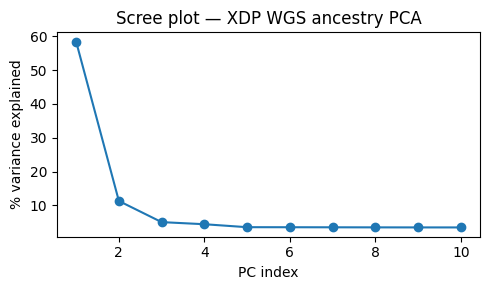

PC scores (first 5 donors):


,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,MS437537,-0.023595,0.032489,-0.094587,0.015615,0.030322,-0.020971,-0.166257,-0.042187,0.083511,-0.008508
1,MS614721,-0.043294,0.027659,-0.077551,0.019851,0.003277,-0.146981,0.056904,0.026985,-0.128528,0.146889
2,MS722238,0.032050,-0.020356,0.011754,0.118916,0.012132,-0.004060,0.022205,-0.004720,0.002410,0.002536
3,MD5334,0.008679,0.225764,-0.269659,-0.056132,-0.028806,0.055024,0.015742,0.123716,0.073863,-0.005052
4,MS107236,0.007796,0.053299,-0.112924,0.020813,0.043659,-0.050567,-0.029726,-0.097178,-0.071701,-0.022092



Variance explained:


,eigenval,PC,pct
0,19.20440,PC1,58.457342
1,3.70480,PC2,11.277247
2,1.64855,PC3,5.018113
3,1.44351,PC4,4.393980
4,1.15476,PC5,3.515038
5,1.15026,PC6,3.501340
6,1.14393,PC7,3.482072
7,1.13762,PC8,3.462865
8,1.13287,PC9,3.448406
9,1.13129,PC10,3.443597


In [25]:
# ── Step 5e: Load PCA results into Python ────────────────────────────────────
# plink2 writes a header starting with "#FID" → strip the "#" to get clean column names.
# eigenvec: one row per donor, columns FID  IID  PC1 ... PC10
# eigenval: one eigenvalue per PC (proportional to variance explained)

pcs = pd.read_csv(f"{VCF_FOLDER}/{PCA_OUT}.eigenvec", sep=r"\s+")
pcs.columns = [c.lstrip("#") for c in pcs.columns]  # "#FID" → "FID"

eigenvals = pd.read_csv(f"{VCF_FOLDER}/{PCA_OUT}.eigenval", header=None, names=["eigenval"])
eigenvals["PC"]  = [f"PC{i+1}" for i in range(len(eigenvals))]
eigenvals["pct"] = eigenvals["eigenval"] / eigenvals["eigenval"].sum() * 100

# Scree plot: shows how much ancestry signal each PC captures.
# A steep elbow indicates the first few PCs explain most genetic structure.
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(range(1, len(eigenvals)+1), eigenvals["pct"], marker="o")
ax.set_xlabel("PC index"); ax.set_ylabel("% variance explained")
ax.set_title("Scree plot — XDP WGS ancestry PCA")
plt.tight_layout(); plt.show()

print("PC scores (first 5 donors):"); display(pcs.head())
print("\nVariance explained:"); display(eigenvals)

### *) kinship removla

In [26]:
# Compute KING kinship from pruned variants
cmd_king = f"""
    podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} \\
    plink2 --pfile {PCA_PGEN_QC} \\
    --extract {PCA_PGEN_PRUNED}.prune.in \\
    --make-king-table \\
    --king-table-filter 0.0442 \\
    --out {PCA_FOLDER}/kinship"""
# --king-table-filter 0.0442 → only print pairs with kinship > 2nd cousin threshold
!{cmd_king}

# Load pairs and greedily remove one from each
import pandas as pd, networkx as nx
king = pd.read_csv(f"{VCF_FOLDER}/{PCA_FOLDER}/kinship.kin0", sep="\t")
king.columns = [c.lstrip("#") for c in king.columns]  # "#FID1" → "FID1"# Build graph: each node = sample, each edge = related pair
display(king)
G = nx.Graph()
for _, row in king.iterrows():
    G.add_edge(row["IID1"], row["IID2"])  # was row["#ID1"] — wrong
# Greedy: remove the node with most connections first
to_remove = set()
while G.number_of_edges() > 0:
    worst = max(G.nodes, key=lambda n: G.degree(n))
    to_remove.add(worst)
    G.remove_node(worst)
print(f"Samples to exclude: {to_remove}")

# # Filter df_gwas to exclude related samples
# df_gwas = df_gwas[~df_gwas.index.isin(to_remove)]
# print(f"GWAS N after kinship pruning: {len(df_gwas)}")


PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to whole_bican_PCA/kinship.log.
Options in effect:
  --extract whole_bican_PCA/vcf_pca_pruned.prune.in
  --king-table-filter 0.0442
  --make-king-table
  --out whole_bican_PCA/kinship
  --pfile whole_bican_PCA/vcf_pca_qc

Start time: Sun Aug  9 17:23:28 2026
314189 MiB RAM detected, ~189148 available; reserving 157094 MiB for main
workspace.
Using up to 48 threads (change this with --threads).
289 samples (0 females, 0 males, 289 ambiguous; 289 founders) loaded from
whole_bican_PCA/vcf_pca_qc.psam.
7984984 variants loaded from whole_bican_PCA/vcf_pca_qc.pvar.
Note: No phenotype data present.
--extract: 235474 variants remaining.
235474 variants remaining after main filters.
--make-king-table pass 1/1: Scanning for rare variants... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555

,IID1,IID2,NSNP,HETHET,IBS0,KINSHIP
0,MD9161,MD9047,235076,0.129499,0.048367,0.051001
1,MD6996,MD9047,235003,0.128926,0.049723,0.045000
2,MD6996,MD9161,235001,0.129289,0.048387,0.049725


Samples to exclude: {'MD9047', 'MD9161'}


# Prepare df with covs for GWAS

In [27]:
# Whole bicna etadata
bican_metatadata = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/BICAN/bican_metadata.csv", index_col=0).drop_duplicates("donor_id").set_index("donor_id")[["age", "imputed_sex"]]
sex_map = {"M": 1, "male": 1, "F": 2, "female": 2}
if bican_metatadata["imputed_sex"].dtype == object:
    bican_metatadata["imputed_sex"] = bican_metatadata["imputed_sex"].map(sex_map)
bican_metatadata.rename(columns={"imputed_sex": "sex"}, inplace=True)
display(bican_metatadata)

,age,sex
donor_id,,
MD6366,31,2
MD6417,46,1
MD6424,55,1
MD6429,27,1
MD6432,28,2
...,...,...
MS216919,72,2
MS5423,90,2
UMBEB23158,59,1


In [28]:
# ── Step 6: Assemble per-donor GWAS table and write plink input files ─────────

# Start from the XDP-only subset of df_meta (computed in the correlations cell above)
df_gwas = df_meta.copy()
df_gwas["donor_id"] = df_gwas.index.copy()
df_gwas.index.name = "index"

print(df_gwas["donor_id"].nunique(), "unique donors in GWAS table")

# Encode sex as integer: plink2 convention = 1 male, 2 female
# "ambiguous" (unknown) is left as NaN and those donors will be dropped below.
df_gwas = pd.merge(df_gwas, bican_metatadata[["sex"]], left_index=True, right_index=True, how="left")

# age_of_death is the only age variable always defined for all donors.
# age_of_onset is 'not_applicable' for controls → not useful here.
# pd.to_numeric(..., errors="coerce") converts any remaining strings to NaN.
df_gwas["age"] = pd.to_numeric(df_gwas["age"], errors="coerce")

# Merge ancestry PCs: IID in pcs matches donor_id in df_gwas (both are index).
# We only bring in the first 3 PCs as covariates (diminishing returns beyond PC3).
df_gwas = df_gwas.merge(
    pcs.set_index("IID")[["PC1", "PC2", "PC3"]],
    left_on="donor_id",   # ← was left_index=True
    right_index=True,
    how="left"
)

print(df_gwas["donor_id"].nunique(), "unique donors in GWAS table")

# Drop any donor missing the trait, PCs, age, sex, or the cell-type covariate.
# These donors cannot be included in the regression.
df_gwas = df_gwas.dropna(
    subset=["m1_z1_trait", "d1d1_z2_cov", "age", "sex", "PC1"]
)

# IID column must match VCF sample names exactly for plink to link files.
df_gwas["IID"] = df_gwas["donor_id"]  # must match VCF sample names in pgen .psam

print(f"Final GWAS N = {len(df_gwas)} donors")
print(f"Final GWAS N = {len(df_gwas)} donors")
display(df_gwas[["IID","m1_z1_trait","d1d1_z2_cov","age","sex","PC1","PC2","PC3"]])

# ── Write phenotype file ──────────────────────────────────────────────────────
# Two-column TSV: IID  m1_z1_trait
# na_rep="NA" ensures plink recognises missing values correctly.
TRAIT     = "m1_z1_trait"
COVS      = ["d1d1_z2_cov", "age", "sex", "PC1", "PC2", "PC3"]
PHENO_FILE   = "subset/gwas_input_covs/pheno.txt"
COVAR_FILE   = "subset/gwas_input_covs/covar.txt"
RESULTS_FILE = "subset/results/results"

os.makedirs(f"{VCF_FOLDER}/subset/gwas_input_covs", exist_ok=True)
os.makedirs(f"{VCF_FOLDER}/subset/results",         exist_ok=True)

pheno = df_gwas[["IID", TRAIT]]
pheno.to_csv(f"{VCF_FOLDER}/{PHENO_FILE}", sep="\t", index=False, na_rep="NA")
print(f"\nPhenotype file written → {PHENO_FILE}  ({len(pheno)} rows)")

# ── Write covariate file ──────────────────────────────────────────────────────
# Columns: IID + all covariates listed in COVS.
# plink reads this and --covar-name selects which columns to actually use.
covar = df_gwas[["IID"] + COVS]
covar.to_csv(f"{VCF_FOLDER}/{COVAR_FILE}", sep="\t", index=False, na_rep="NA")
print(f"Covariate file written  → {COVAR_FILE}  (covariates: {COVS})")

114 unique donors in GWAS table
114 unique donors in GWAS table
Final GWAS N = 99 donors
Final GWAS N = 99 donors


,IID,m1_z1_trait,d1d1_z2_cov,age,sex,PC1,PC2,PC3
index,,,,,,,,
MS323252,MS323252,1.745127,0.421875,90,1.0,0.030381,-0.010925,0.028111
MD6574,MD6574,0.393901,0.408360,46,1.0,0.039198,-0.022448,0.018593
MS68083,MS68083,-1.135854,0.032885,90,2.0,0.039012,-0.011022,0.018717
MS581663,MS581663,1.652325,0.675889,66,1.0,-0.138706,-0.023698,0.012342
MD6670,MD6670,1.995835,0.673139,40,1.0,0.037058,-0.024119,0.008795
...,...,...,...,...,...,...,...,...
PT13717,PT13717,-1.018303,0.149733,44,1.0,-0.109076,-0.023116,0.006616
PT13641,PT13641,1.178714,0.658960,42,2.0,-0.116483,-0.022191,0.014800
PT13702,PT13702,-1.271640,0.155405,41,2.0,0.038928,-0.021206,0.013959



Phenotype file written → subset/gwas_input_covs/pheno.txt  (99 rows)
Covariate file written  → subset/gwas_input_covs/covar.txt  (covariates: ['d1d1_z2_cov', 'age', 'sex', 'PC1', 'PC2', 'PC3'])


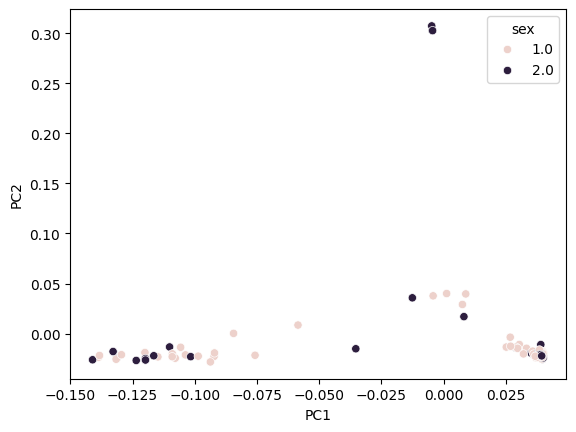

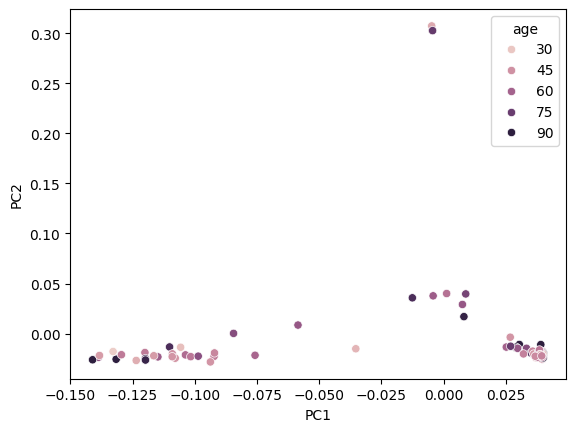

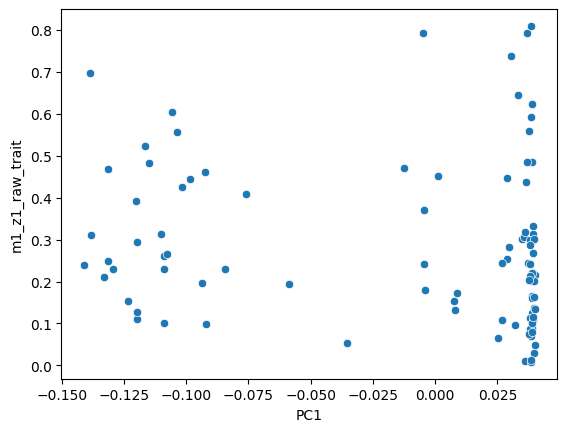

In [29]:
sns.scatterplot(data=df_gwas, x="PC1", y="PC2", hue="sex"); plt.show()
sns.scatterplot(data=df_gwas, x="PC1", y="PC2", hue="age"); plt.show()
sns.scatterplot(data=df_gwas, x="PC1", y="m1_z1_raw_trait"); plt.show()

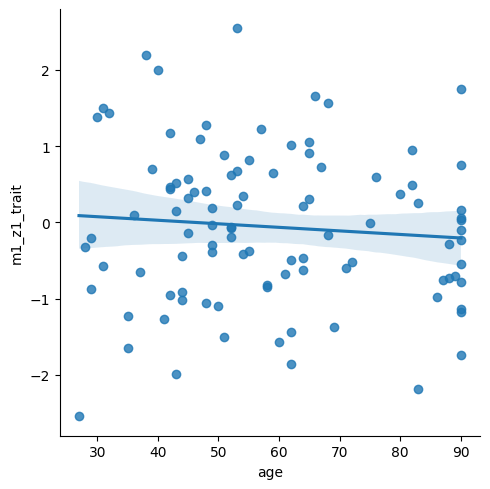

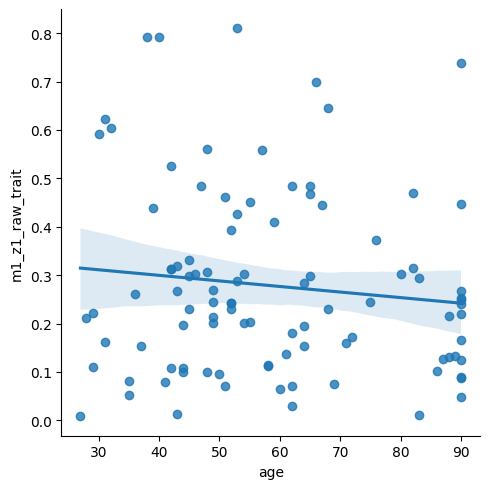

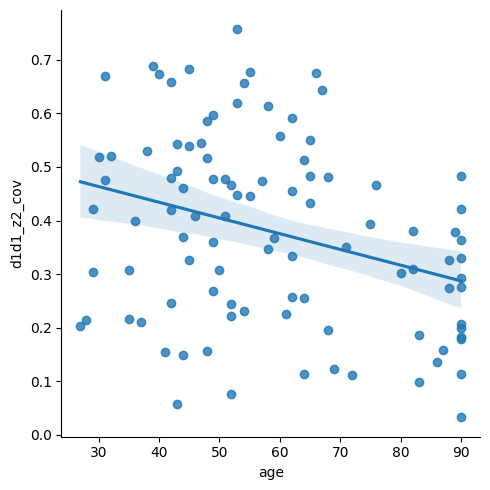

In [30]:
sns.lmplot(data=df_gwas, x="age", y="m1_z1_trait"); plt.show()
sns.lmplot(data=df_gwas, x="age", y="m1_z1_raw_trait"); plt.show()

sns.lmplot(data=df_gwas, x="age", y="d1d1_z2_cov"); plt.show()

# Run GWAS

In [32]:
# ── Step 7: Run plink2 linear regression ─────────────────────────────────────
# --pfile {SUBSET_PGEN}_qc        → QC-filtered candidate-region pgen (MAF>5%,
#                                   geno<5%, 1 bad sample removed by --mind)
# --pheno / --pheno-name          → phenotype file and which column to use as trait
# --covar / --covar-name          → covariate file and column list
# --glm hide-covar                → ordinary least squares per variant;
#                                   "hide-covar" suppresses the rows for each
#                                   covariate (we only want the SNP rows)
# --covar-variance-standardize    → z-score all covariates before fitting
#                                   (does not change p-values; keeps BETA scale
#                                    comparable across covariates)
#    --glm hide-covar no-x-sex \ 
#           plink2 auto-adds its own internal sex predictor for chrX variants; since you already pass sex via --covar-name, that produced a duplicate column → singular covariate matrix 
# Output file: {RESULTS_FILE}.{TRAIT}.glm.linear

cmd = f"""
  podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} \\
    plink2 --pfile {SUBSET_PGEN_NORM} \\
    --pheno {PHENO_FILE} --pheno-name {TRAIT} \\
    --covar {COVAR_FILE} --covar-name {",".join(COVS)} \\
    --glm hide-covar no-x-sex \\
    --covar-variance-standardize \\
    --out {RESULTS_FILE}
  """
print(cmd)
!{cmd}


  podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0 \
    plink2 --pfile subset/plink/candidate_norm \
    --pheno subset/gwas_input_covs/pheno.txt --pheno-name m1_z1_trait \
    --covar subset/gwas_input_covs/covar.txt --covar-name d1d1_z2_cov,age,sex,PC1,PC2,PC3 \
    --glm hide-covar no-x-sex \
    --covar-variance-standardize \
    --out subset/results/results
  
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to subset/results/results.log.
Options in effect:
  --covar subset/gwas_input_covs/covar.txt
  --covar-name d1d1_z2_cov,age,sex,PC1,PC2,PC3
  --covar-variance-standardize
  --glm hide-covar no-x-sex
  --out subset/results/results
  --pfile subset/plink/candidate_norm
  --pheno subset/gwas_input_covs/pheno.txt
  --pheno-name m1_z1_trait

Start time: Sun Aug  9 17:23:33 2026
314189 

# Analyse GWAS results

In [ ]:
TRAIT     = "m1_z1_trait"
COVS      = ["d1d1_z2_cov", "age", "sex", "PC1", "PC2", "PC3"]
PHENO_FILE   = "subset/gwas_input_covs/pheno.txt"
COVAR_FILE   = "subset/gwas_input_covs/covar.txt"
RESULTS_FILE = "subset/results/results"

/tmp/ipykernel_89897/4055138146.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  res = pd.read_csv(


Total variants tested: 8405750
Testable variants (MAF > 10%, non-NaN p): 6459068

Top 10 associations:


,#CHROM,POS,ID,REF,ALT,PROVISIONAL_REF?,A1,OMITTED,A1_FREQ,TEST,OBS_CT,BETA,SE,T_STAT,P,ERRCODE,padj
7478567,18,71989515,18:71989515:T:C,T,C,N,C,T,0.186869,ADD,99,-0.631268,0.116047,-5.43975,4.461900e-07,.,1.0
7478563,18,71987680,18:71987680:TA:T,TA,T,N,T,TA,0.186869,ADD,99,-0.631268,0.116047,-5.43975,4.461900e-07,.,1.0
7478564,18,71987996,18:71987996:G:T,G,T,N,T,G,0.171717,ADD,99,-0.665502,0.122861,-5.41669,4.919090e-07,.,1.0
3136575,6,38996473,6:38996473:G:C,G,C,N,C,G,0.348485,ADD,99,-0.569235,0.105349,-5.40331,5.204920e-07,.,1.0
7524858,19,4488952,19:4488952:CT:C,CT,C,N,C,CT,0.463918,ADD,97,0.471870,0.087505,5.39251,5.661190e-07,.,1.0
7573837,19,18784408,19:18784408:G:A,G,A,N,A,G,0.301020,ADD,98,-0.491465,0.092462,-5.31534,7.672570e-07,.,1.0
2838980,5,129358197,5:129358197:A:G,A,G,N,G,A,0.343434,ADD,99,0.575872,0.109316,5.26796,9.184160e-07,.,1.0
7478557,18,71984504,18:71984504:T:C,T,C,N,C,T,0.191919,ADD,99,-0.610291,0.116530,-5.23719,1.044020e-06,.,1.0
7573827,19,18781918,19:18781918:C:A,C,A,N,A,C,0.292929,ADD,99,-0.502882,0.096430,-5.21498,1.144940e-06,.,1.0
7478575,18,71991927,18:71991927:A:T,A,T,N,T,A,0.176768,ADD,99,-0.643361,0.123481,-5.21021,1.167820e-06,.,1.0


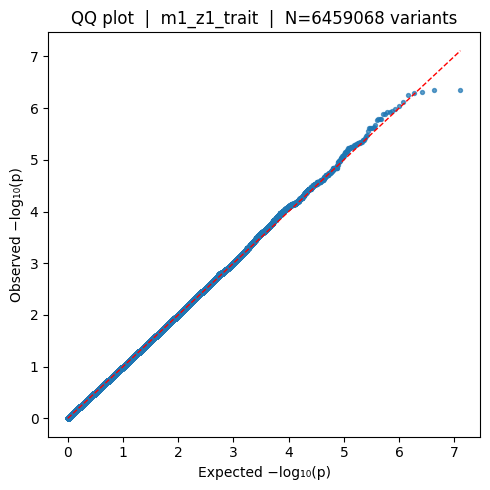

In [8]:
# ── Step 8: Load, filter, and visualise GWAS results ─────────────────────────
import numpy as np

# Load the linear regression results produced by plink2.
# Columns: #CHROM POS ID REF ALT A1 A1_FREQ TEST OBS_CT BETA SE T_STAT P ERRCODEà

res = pd.read_csv(
    f"{VCF_FOLDER}/{RESULTS_FILE}.{TRAIT}.glm.linear", sep="\t"
)
print(f"Total variants tested: {len(res)}")

import statsmodels.stats.multitest as smm
res["padj"] = smm.multipletests(res["P"], method="bonferroni")[1]  # Bonferroni

# ── 8a. Filter to testable variants ───────────────────────────────────────────
# Keep only variants where:
#   - A1_FREQ is between 0.10 and 0.90 (MAF > 10%)
#     Very rare variants are unreliable with small N: a single carrier 
#     dominates the regression and inflates the effect size.
#   - P is not NaN: NaN means the variant is monomorphic or perfectly collinear
#     with a covariate (plink reports ERRCODE = CONST_OMITTED_ALLELE).
testable = res[
    (res["A1_FREQ"] > 0.10) & (res["A1_FREQ"] < 0.90) & res["P"].notna()
].copy()
print(f"Testable variants (MAF > 10%, non-NaN p): {len(testable)}")

# ── 8b. Top associations ──────────────────────────────────────────────────────
# Multiple variants with identical BETA/SE/P → perfect LD (same haplotype).
# They represent the same signal; the first hit summarises it.
print("\nTop 10 associations:")
display(
    testable.sort_values("P").head(10)
              #[["#CHROM", "POS", "ID", "A1", "A1_FREQ", "OBS_CT", "BETA", "SE", "P"]]
)

# ── 8c. QQ plot ───────────────────────────────────────────────────────────────
# Compares observed −log10(p) distribution vs the expected null (uniform).
# Interpretation:
#   - Bulk of points on the red diagonal → well-calibrated (no inflation)
#   - Bulk above the diagonal → λ > 1, potential confounding
#   - Only the top few points above the line → plausible true signal
p_vals   = testable["P"].sort_values().values
n        = len(p_vals)
expected = -np.log10((np.arange(1, n + 1) - 0.5) / n)  # theoretical uniform quantiles
observed = -np.log10(p_vals)



fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(expected, observed, s=8, alpha=0.7)
ax.plot([0, expected.max()], [0, expected.max()], "r--", lw=1)  # null diagonal
ax.set_xlabel("Expected −log₁₀(p)")
ax.set_ylabel("Observed −log₁₀(p)")
ax.set_title(f"QQ plot  |  {TRAIT}  |  N={n} variants")
plt.tight_layout(); plt.show()

/tmp/ipykernel_89897/2032562641.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_plot["-logP"] = -np.log10(res_plot["P"])
/tmp/ipykernel_89897/2032562641.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_plot["chrom"] = res_plot["#CHROM"].astype(str)
/tmp/ipykernel_89897/2032562641.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

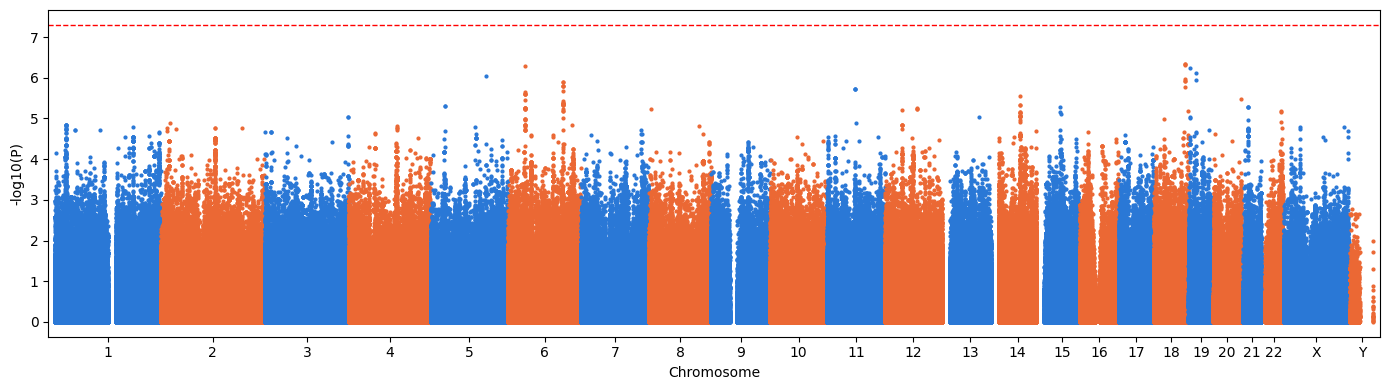

In [15]:
res_plot = res[~res["#CHROM"].isin(["PAR1", "PAR2"])]



res_plot["-logP"] = -np.log10(res_plot["P"])
res_plot["chrom"] = res_plot["#CHROM"].astype(str)

# Natural chromosome order, derived from whatever chrom strings are actually in
# the data (handles "chr1"/"1", "chrX"/"X", "chrM"/"chrMT", ... alike) so no
# chromosome can silently fall outside the categories and turn into NaN.
def _chrom_sort_key(c):
    s = c[3:] if c.startswith("chr") else c
    if s.isdigit():
        return (0, int(s))
    return (1, {"X": 0, "Y": 1, "M": 2, "MT": 2}.get(s, 99))

chrom_order = sorted(res_plot["chrom"].unique(), key=_chrom_sort_key)
res_plot["chrom"] = pd.Categorical(res_plot["chrom"], categories=chrom_order, ordered=True)
res_plot = res_plot.sort_values(["chrom", "POS"])

# Cumulative x-offset per chromosome so points lay out left-to-right along the genome
offsets, cum = {}, 0
for chrom in chrom_order:
    offsets[chrom] = cum
    cum += res_plot.loc[res_plot["chrom"] == chrom, "POS"].max() + 1
res_plot["x"] = res_plot["POS"] + res_plot["chrom"].astype(str).map(offsets)

fig, ax = plt.subplots(figsize=(14, 4))
colors = ["#2a78d6", "#eb6834"]   # blue / orange
tick_pos, tick_lab = [], []
for i, chrom in enumerate(chrom_order):
    sub = res_plot[res_plot["chrom"] == chrom]
    ax.scatter(sub["x"], sub["-logP"], s=4, color=colors[i % 2])
    tick_pos.append((sub["x"].min() + sub["x"].max()) / 2)
    tick_lab.append(chrom.replace("chr", ""))

ax.axhline(-np.log10(5e-8), color="red", ls="--", lw=1)      # genome-wide sig
#ax.axhline(-np.log10(1e-5), color="grey", ls="--", lw=1)     # suggestive
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lab)
ax.set_xlim(res_plot["x"].min() - 0.005 * res_plot["x"].max(), res_plot["x"].max() * 1.005)
ax.set_xlabel("Chromosome"); ax.set_ylabel("-log10(P)")
#ax.set_title(f"Manhattan plot | {TRAIT}")
plt.tight_layout(); plt.show()


In [12]:
res = pd.read_csv(f"{VCF_FOLDER}/{RESULTS_FILE}.{TRAIT}.glm.linear", sep="\t")
print(res.shape)
print(res.columns.tolist())
res.head()

/tmp/ipykernel_89897/399063023.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  res = pd.read_csv(f"{VCF_FOLDER}/{RESULTS_FILE}.{TRAIT}.glm.linear", sep="\t")


(8405750, 16)
['#CHROM', 'POS', 'ID', 'REF', 'ALT', 'PROVISIONAL_REF?', 'A1', 'OMITTED', 'A1_FREQ', 'TEST', 'OBS_CT', 'BETA', 'SE', 'T_STAT', 'P', 'ERRCODE']


,#CHROM,POS,ID,REF,ALT,PROVISIONAL_REF?,A1,OMITTED,A1_FREQ,TEST,OBS_CT,BETA,SE,T_STAT,P,ERRCODE
0,1,15274,1:15274:A:T,A,T,N,A,T,0.318182,ADD,99,-0.037144,0.157644,-0.235621,0.814256,.
1,1,15274,1:15274:A:G,A,G,N,G,A,0.313131,ADD,99,-0.041865,0.161295,-0.259553,0.795795,.
2,1,101304,1:101304:C:T,C,T,N,T,C,0.142105,ADD,95,0.056776,0.169709,0.334546,0.738773,.
3,1,103234,1:103234:G:A,G,A,N,A,G,0.087629,ADD,97,0.012404,0.219225,0.056580,0.955007,.
4,1,104697,1:104697:G:T,G,T,N,G,T,0.190722,ADD,97,-0.048548,0.140406,-0.345767,0.730334,.


In [13]:
testable = res[(res["A1_FREQ"] > 0.10) & (res["A1_FREQ"] < 0.90)].copy()

testable.sort_values("P").head(10)

,#CHROM,POS,ID,REF,ALT,PROVISIONAL_REF?,A1,OMITTED,A1_FREQ,TEST,OBS_CT,BETA,SE,T_STAT,P,ERRCODE
7478567,18,71989515,18:71989515:T:C,T,C,N,C,T,0.186869,ADD,99,-0.631268,0.116047,-5.43975,4.461900e-07,.
7478563,18,71987680,18:71987680:TA:T,TA,T,N,T,TA,0.186869,ADD,99,-0.631268,0.116047,-5.43975,4.461900e-07,.
7478564,18,71987996,18:71987996:G:T,G,T,N,T,G,0.171717,ADD,99,-0.665502,0.122861,-5.41669,4.919090e-07,.
3136575,6,38996473,6:38996473:G:C,G,C,N,C,G,0.348485,ADD,99,-0.569235,0.105349,-5.40331,5.204920e-07,.
7524858,19,4488952,19:4488952:CT:C,CT,C,N,C,CT,0.463918,ADD,97,0.471870,0.087505,5.39251,5.661190e-07,.
7573837,19,18784408,19:18784408:G:A,G,A,N,A,G,0.301020,ADD,98,-0.491465,0.092462,-5.31534,7.672570e-07,.
2838980,5,129358197,5:129358197:A:G,A,G,N,G,A,0.343434,ADD,99,0.575872,0.109316,5.26796,9.184160e-07,.
7478557,18,71984504,18:71984504:T:C,T,C,N,C,T,0.191919,ADD,99,-0.610291,0.116530,-5.23719,1.044020e-06,.
7573827,19,18781918,19:18781918:C:A,C,A,N,A,C,0.292929,ADD,99,-0.502882,0.096430,-5.21498,1.144940e-06,.
7478575,18,71991927,18:71991927:A:T,A,T,N,T,A,0.176768,ADD,99,-0.643361,0.123481,-5.21021,1.167820e-06,.


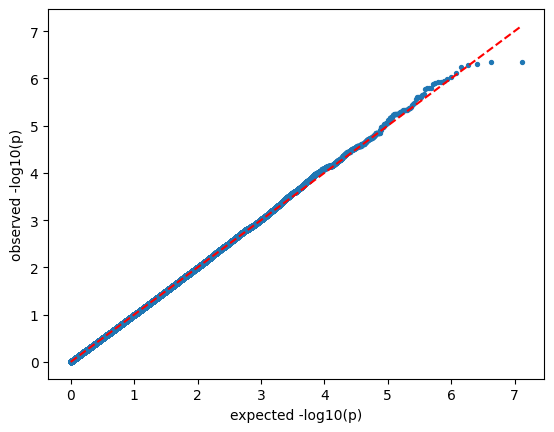

In [37]:
import numpy as np, matplotlib.pyplot as plt
p = testable["P"].dropna().sort_values().values
exp = -np.log10((np.arange(1, len(p)+1) - 0.5) / len(p))
obs = -np.log10(p)
plt.scatter(exp, obs, s=8); plt.plot([0,exp.max()],[0,exp.max()],'r--')
plt.xlabel("expected -log10(p)"); plt.ylabel("observed -log10(p)"); plt.show()